# 01_DTC_Without_DR

## Baseline Decision Tree Classifier (Without Dimensionality Reduction)

This notebook trains the baseline DTC model on the original feature space (no dimensionality reduction). It evaluates model performance on the existing test split and saves all outputs into `results/`.


In [9]:
from pathlib import Path
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

sns.set_style("whitegrid")
ROOT = Path.cwd()
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Results directory is ready.")

from sklearn.tree import DecisionTreeClassifier, plot_tree


Results directory is ready.


### Load Original Train/Test Data

This experiment uses all original features from the prepared split files. No new splitting or preprocessing is performed here.


In [10]:
x_train_path = ROOT / "train" / "X_train.csv"
x_test_path = ROOT / "test" / "X_test.csv"

if not x_train_path.exists():
    x_train_path = ROOT / "train" / "x_train.csv"
if not x_test_path.exists():
    x_test_path = ROOT / "test" / "x_test.csv"

y_train_path = ROOT / "train" / "y_train.csv"
y_test_path = ROOT / "test" / "y_test.csv"

X_train = pd.read_csv(x_train_path)
X_test = pd.read_csv(x_test_path)
y_train = pd.read_csv(y_train_path).squeeze()
y_test = pd.read_csv(y_test_path).squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (4930, 30)
X_test: (2113, 30)
y_train: (4930,)
y_test: (2113,)


### Train Baseline DTC

Model configuration:
- `random_state=42`
- `max_depth=5`
- `min_samples_leaf=10`


In [11]:
dtc = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=10)
dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)


### Evaluate Performance

In [12]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
}

metrics_df = pd.DataFrame([metrics])
metrics_path = RESULTS_DIR / "dtc_without_dr_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("Baseline DTC metrics:")
print(metrics_df.to_string(index=False))
print("\nSaved metrics CSV to results/.")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

comparison_script = ROOT / "scripts" / "update_model_comparison.py"
if comparison_script.exists():
    subprocess.run(["python", str(comparison_script)], check=False)
    print("Updated model_comparison_results.csv")


Baseline DTC metrics:
 Accuracy  Precision   Recall  F1-score
 0.788452   0.622318 0.516934  0.564752

Saved metrics CSV to results/.

Confusion Matrix:
[[1376  176]
 [ 271  290]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1552
           1       0.62      0.52      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



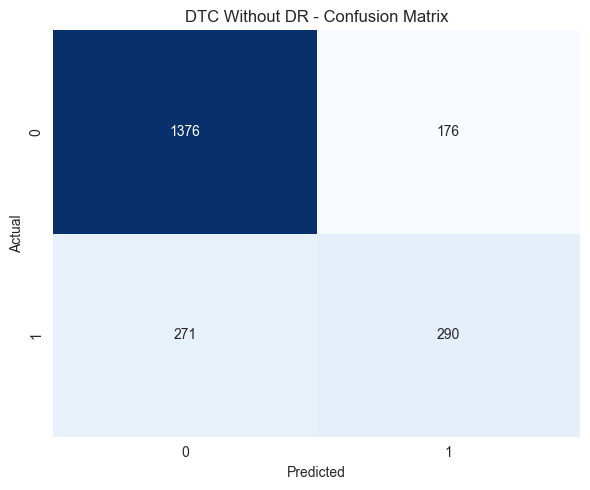

Saved confusion matrix plot to results/.


In [13]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("DTC Without DR - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
cm_path = RESULTS_DIR / "dtc_without_dr_confusion_matrix.png"
plt.tight_layout()
plt.savefig(cm_path, dpi=300)
plt.show()
print("Saved confusion matrix plot to results/.")


### Feature Importance and Tree Interpretation

The following figures show:
- the most important features in the trained baseline tree
- a readable tree structure (visualized with limited depth)

These help interpret which variables drive the model decisions and the main visible split logic.


Top feature importances:
                           feature  importance
                            tenure    0.406275
       InternetService_Fiber optic    0.325114
                      TotalCharges    0.062376
  OnlineBackup_No internet service    0.041546
    PaymentMethod_Electronic check    0.036904
                 Contract_Two year    0.033010
                 Contract_One year    0.031263
              PaperlessBilling_Yes    0.019560
                    MonthlyCharges    0.015590
                 MultipleLines_Yes    0.014988
                     SeniorCitizen    0.005200
                OnlineSecurity_Yes    0.003863
               StreamingMovies_Yes    0.003304
    MultipleLines_No phone service    0.001008
OnlineSecurity_No internet service    0.000000


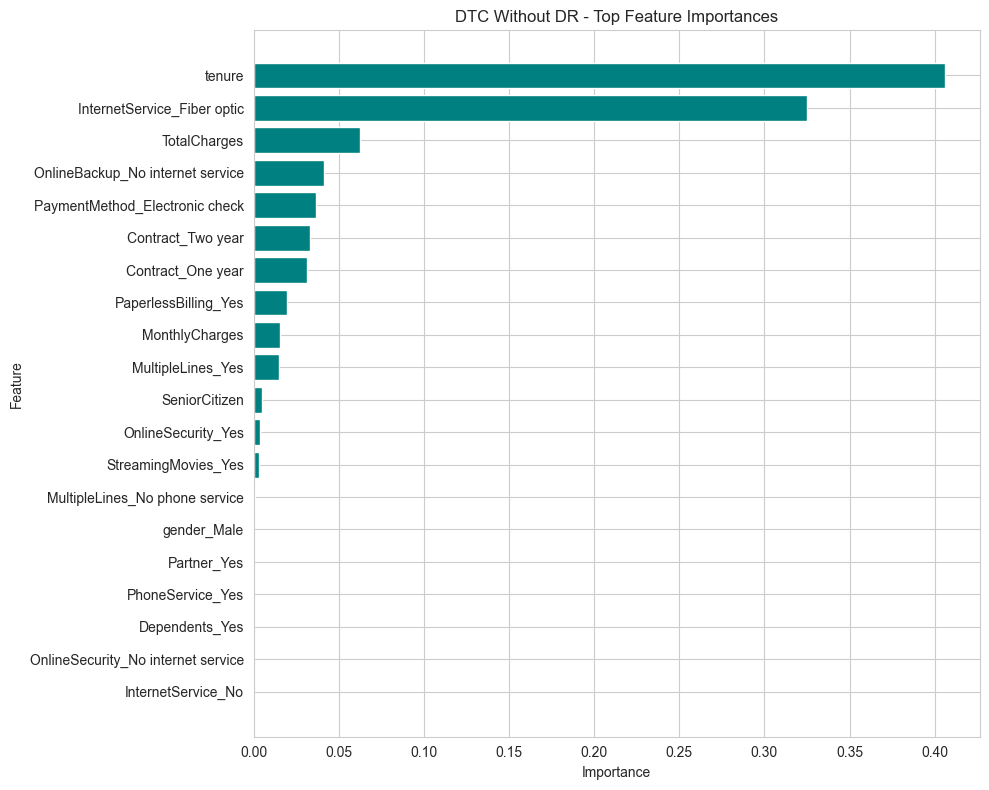

Saved feature importance plot to results/.


In [14]:
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dtc.feature_importances_
}).sort_values("importance", ascending=False)

print("Top feature importances:")
print(feature_importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
plot_df = feature_importance_df.head(20).sort_values("importance", ascending=True)
plt.barh(plot_df["feature"], plot_df["importance"], color="teal")
plt.title("DTC Without DR - Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
fi_path = RESULTS_DIR / "dtc_final_feature_importance.png"
plt.tight_layout()
plt.savefig(fi_path, dpi=300)
plt.show()
print("Saved feature importance plot to results/.")


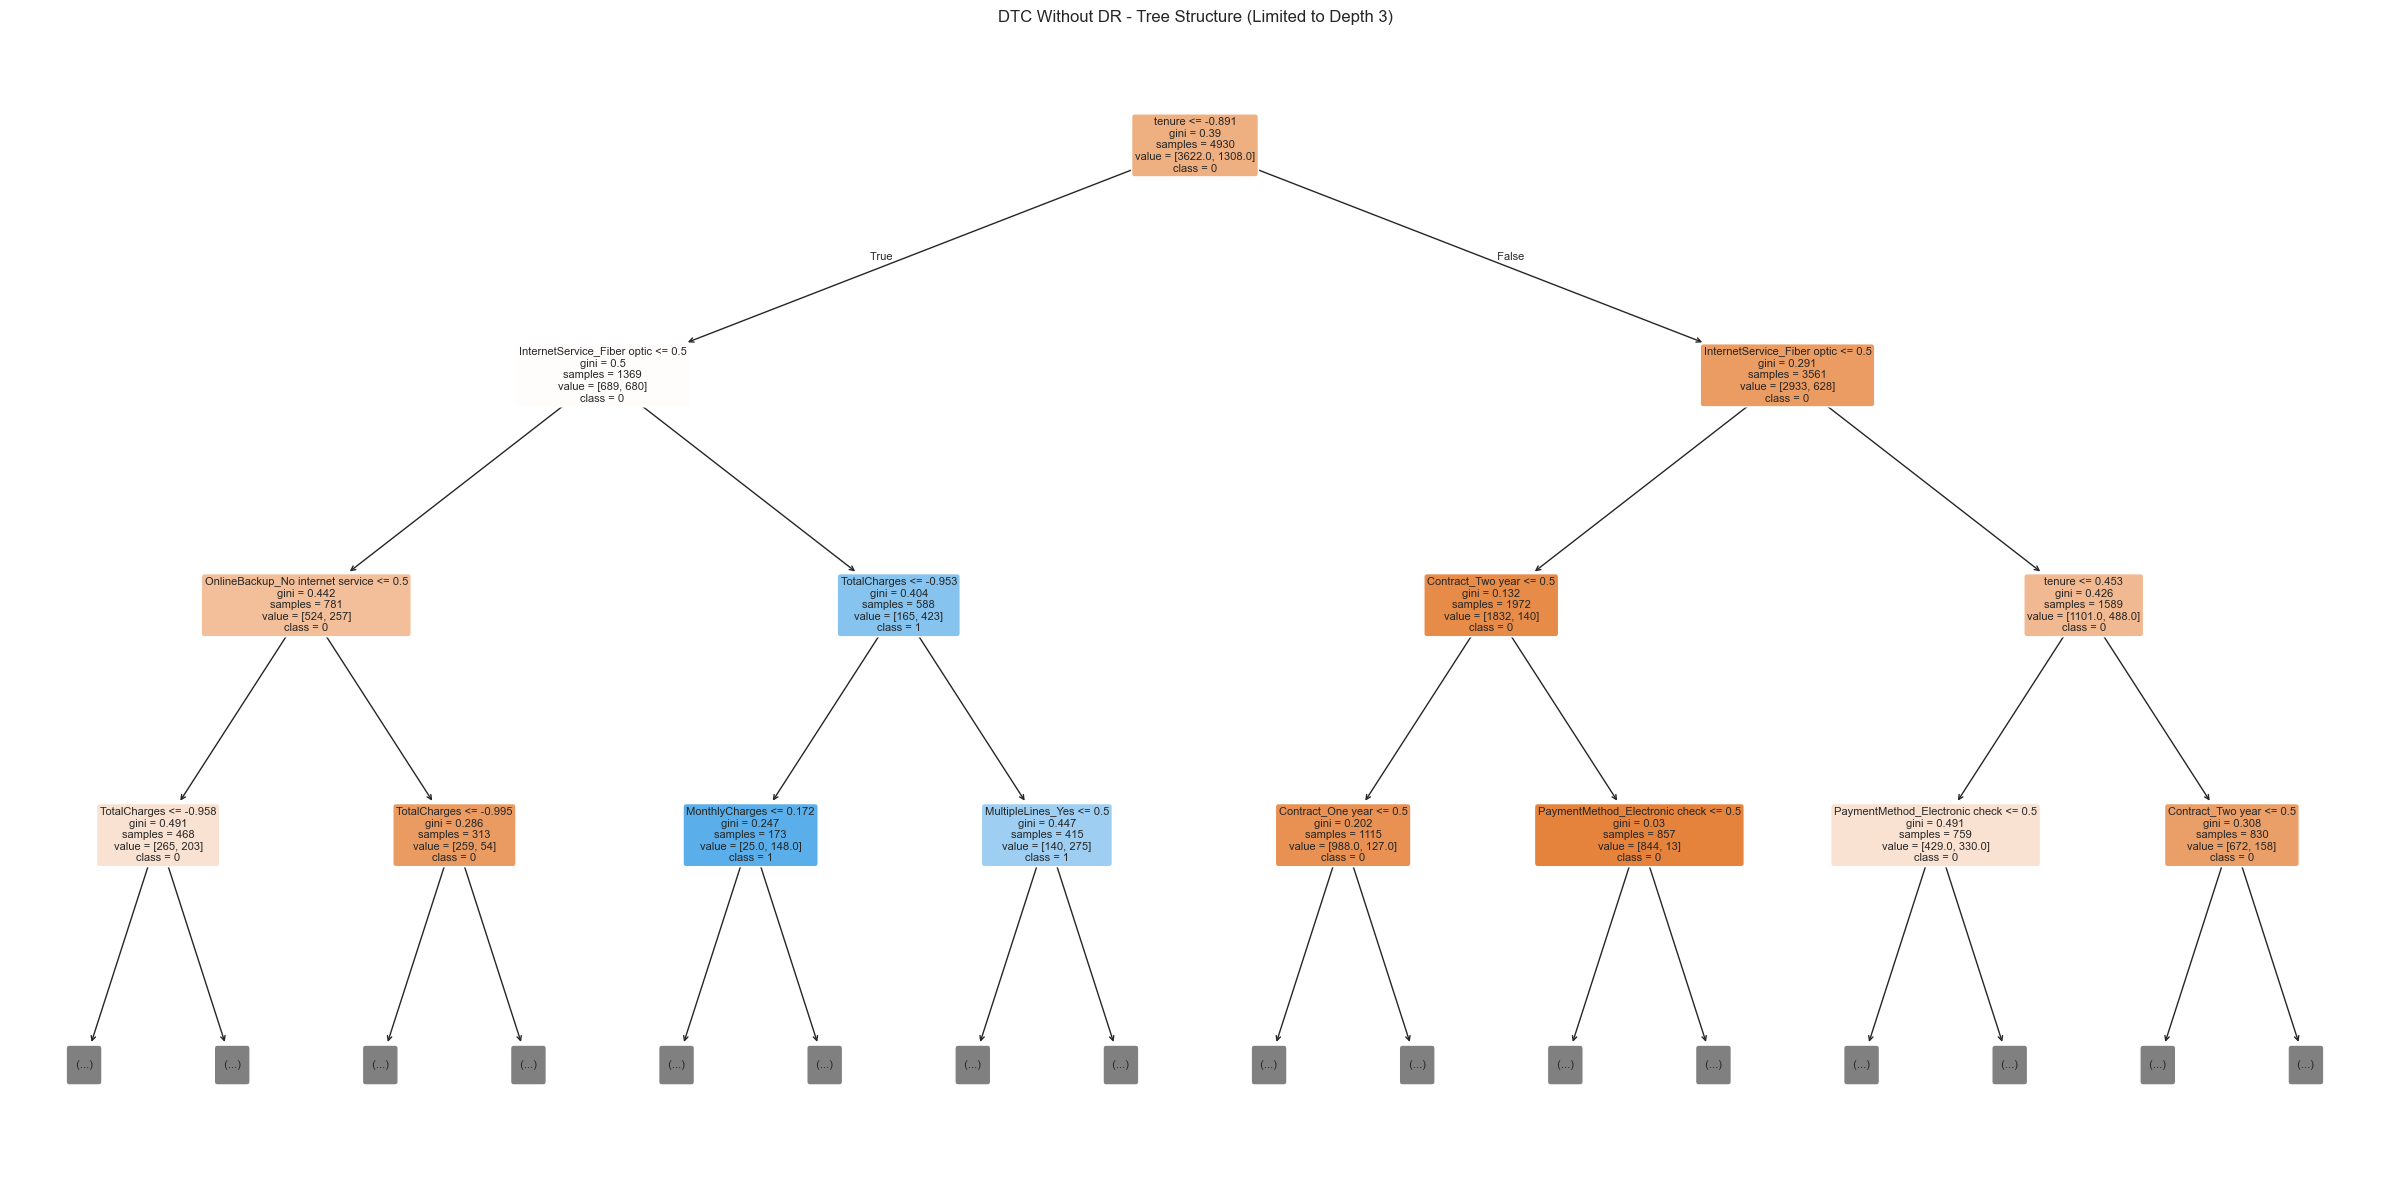

Saved tree structure plot to results/.


In [15]:
plt.figure(figsize=(24, 12))
plot_tree(
    dtc,
    feature_names=X_train.columns,
    class_names=[str(c) for c in sorted(pd.Series(y_train).unique())],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("DTC Without DR - Tree Structure (Limited to Depth 3)")
tree_path = RESULTS_DIR / "dtc_tree_structure.png"
plt.tight_layout()
plt.savefig(tree_path, dpi=300)
plt.show()
print("Saved tree structure plot to results/.")


In [16]:
print("\nExperiment completed successfully.")
print("Results (metrics CSV and confusion matrix plot) were saved in the results/ directory.")
print("Use Accuracy, Precision, Recall, and F1-score together for balanced model evaluation.")



Experiment completed successfully.
Results (metrics CSV and confusion matrix plot) were saved in the results/ directory.
Use Accuracy, Precision, Recall, and F1-score together for balanced model evaluation.
